# Modeling - severity, garage choice, and the combined ranking

Three parts here:
1. **Severity model** - predicts repair cost in NIS, conditioned on the claim and the garage.
2. **Choice model** - predicts the probability an insured picks each candidate garage.
3. **Combined ranking** - merges the two into a ranked garage list per claim, balancing likelihood to go there against expected cost.

Each model starts from a simple baseline, moves to a LightGBM pipeline with light Optuna tuning (cross validation inside train only), and is checked for overfitting with a train / CV / test comparison. Everything that learns from data - imputation, encoding, the model itself - lives inside a sklearn Pipeline, so it's fit on train only and saved as one artifact at the end.

## Imports and loading

In [1]:
import json
import os
import warnings

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm
import sklearn
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

SEED = 42
os.makedirs("models", exist_ok=True)

severity = pd.read_csv("data/severity_panel.csv")
choice = pd.read_csv("data/choice_panel.csv")
garages = pd.read_csv("data/garages.csv")

print(f"severity panel: {severity.shape}")
print(f"choice panel:   {choice.shape}")

severity panel: (2000, 16)
choice panel:   (200000, 22)


## Metric helpers

For severity: MAE and RMSE in NIS (interpretable for the business), WAPE (total absolute error over total cost - the number a pricing team actually tracks), and R2 as context.

For choice: with one positive out of 100 candidates per claim, row-level accuracy is meaningless (99% by predicting all zeros). This is a ranking problem, so the metrics are recall@k (is the actually-chosen garage in our top k), MRR, and the mean rank of the chosen garage. Log loss is added on top because the probabilities feed the combined ranking, so they need to be calibrated, not just well-ordered.

In [2]:
def regression_report(y_true, y_pred) -> dict:
    """Business-facing regression metrics, all in NIS."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": np.abs(y_true - y_pred).sum() / y_true.sum(),
        "R2": r2_score(y_true, y_pred),
    }


def ranking_report(frame: pd.DataFrame, score_col: str) -> dict:
    """Ranking metrics for the choice problem: rank candidates within each claim by score."""
    g = frame.copy()
    g["rank"] = g.groupby("claim_id")[score_col].rank(ascending=False, method="first")
    chosen = g.loc[g["chosen"] == 1, "rank"]
    return {
        "recall@1": (chosen <= 1).mean(),
        "recall@3": (chosen <= 3).mean(),
        "recall@5": (chosen <= 5).mean(),
        "MRR": (1 / chosen).mean(),
        "mean_rank": chosen.mean(),
    }

# Part 1 - Severity model

## Setup and baselines

Two baselines before any GBM:
- **Naive:** the train median cost per `damage_type` (fallback to the global train median). If the model can't clearly beat this, it's not earning its complexity.
- **Ridge regression:** a simple linear model on the same features. Scaling and one-hot encoding sit inside its pipeline, so they're fit on train only. Trees don't need scaling, so the LightGBM pipeline skips it - that's exactly why preprocessing lives per-pipeline and not in the panel.

In [3]:
# feature groups by how they're treated. Only fields with genuine quality issues
# in the data get an imputer: driver_age (outliers, any model) and the distance
# built from possibly-missing coordinates (imputed for linear models only - trees handle NaN natively).
# Everything else is required at inference and passes through untouched.
sev_impute = ["driver_age"]
sev_dist = ["dist_km"]
sev_pass = ["vehicle_age", "vehicle_value_nis", "insured_city_ses_cluster",
            "garage_city_ses_cluster", "driver_age_was_imputed"]
sev_cat = ["damage_type", "car_manufacturer", "insured_city_type", "opened_by", "garage_city_type"]
sev_features = sev_impute + sev_dist + sev_pass + sev_cat

sev_train = severity[severity["split"] == "train"]
sev_test = severity[severity["split"] == "test"]

X_sev_train, y_sev_train = sev_train[sev_features], sev_train["damage_cost_nis"]
X_sev_test, y_sev_test = sev_test[sev_features], sev_test["damage_cost_nis"]

print(f"train: {X_sev_train.shape}, test: {X_sev_test.shape}")

train: (1600, 12), test: (400, 12)


In [4]:
# naive baseline - train median cost per damage type
median_by_type = sev_train.groupby("damage_type")["damage_cost_nis"].median()
global_median = sev_train["damage_cost_nis"].median()
naive_pred = sev_test["damage_type"].map(median_by_type).fillna(global_median)

naive_metrics = regression_report(y_sev_test, naive_pred)
print("naive baseline (median by damage_type):", {k: round(v, 3) for k, v in naive_metrics.items()})

naive baseline (median by damage_type): {'MAE': 2174.195, 'RMSE': np.float64(2805.74), 'WAPE': np.float64(0.273), 'R2': 0.392}


In [5]:
# ridge baseline - linear model with scaling, log target handled by TransformedTargetRegressor
ridge_prep = ColumnTransformer([
    ("age", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), sev_impute),
    ("dist", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), sev_dist),
    ("num", StandardScaler(), sev_pass),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), sev_cat),
])
ridge_model = TransformedTargetRegressor(
    regressor=Pipeline([("prep", ridge_prep), ("model", Ridge(alpha=1.0, random_state=SEED))]),
    func=np.log1p, inverse_func=np.expm1,
)
ridge_model.fit(X_sev_train, y_sev_train)

ridge_metrics = regression_report(y_sev_test, ridge_model.predict(X_sev_test))
print("ridge baseline:", {k: round(v, 3) for k, v in ridge_metrics.items()})

ridge baseline: {'MAE': 2162.239, 'RMSE': np.float64(2787.882), 'WAPE': np.float64(0.272), 'R2': 0.4}


## LightGBM pipeline

Same structure, different model, and imputation scoped deliberately: only `driver_age` gets a median imputer (fit on train - the ~1% invalid ages arrive as NaN and get the train median, in any model). Distance can be NaN when coordinates are unknown - LightGBM handles missing values natively, so it passes through here, while the linear baseline imputes it inside its own pipeline. All other features are required at inference and pass through untouched - no silent completion of fields that were never missing in the data. The log target is wrapped by `TransformedTargetRegressor`, so the transform is part of the saved artifact and can't be forgotten at inference.

On the categoricals in this data: everything used here is low/medium cardinality (damage_type 6 levels, city types 3, opened_by 2, manufacturer 25), so one-hot with `handle_unknown="ignore"` is enough. The high-cardinality IDs (`insured_city_id` with 120 levels, `garage_id` with 150) are deliberately not one-hot encoded - the cities are already represented through SES cluster, locality type and distance, and the garage identity enters the choice model through the smoothed popularity share, which is effectively a target encoding.

In [6]:
def make_severity_model(**lgbm_params) -> TransformedTargetRegressor:
    """Full severity pipeline: impute + encode + LGBM, log target inside."""
    prep = ColumnTransformer([
        ("age", SimpleImputer(strategy="median"), sev_impute),
        ("num", "passthrough", sev_dist + sev_pass),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), sev_cat),
    ])
    model = LGBMRegressor(random_state=SEED, verbosity=-1, **lgbm_params)
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", prep), ("model", model)]),
        func=np.log1p, inverse_func=np.expm1,
    )

## Light tuning with Optuna

Small search space, 25 trials, and the objective is the mean MAE (in NIS) over 5-fold cross validation **inside train only** - the test set stays untouched until the final evaluation. Plain shuffled KFold is fine here since the representation check in Step 2 showed no temporal drift in the data.

In [7]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)


def severity_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }
    scores = cross_val_score(
        make_severity_model(**params), X_sev_train, y_sev_train,
        cv=cv5, scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    return -scores.mean()


sev_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
sev_study.optimize(severity_objective, n_trials=25, show_progress_bar=False)

print(f"best CV MAE: {sev_study.best_value:,.0f} NIS")
print("best params:", sev_study.best_params)

best CV MAE: 2,438 NIS
best params: {'n_estimators': 200, 'learning_rate': 0.020105800546376732, 'num_leaves': 8, 'min_child_samples': 25, 'subsample': 0.6978753170579768, 'colsample_bytree': 0.865362571444793, 'reg_lambda': 1.6258592286865041}


## Results and overfitting check

Fitting the best configuration on the full train split, then comparing train / CV / test errors side by side. What we want to see is all three in the same range - a large train-test gap would be the cue to regularize harder.

In [8]:
severity_model = make_severity_model(**sev_study.best_params)
severity_model.fit(X_sev_train, y_sev_train)

sev_pred_train = severity_model.predict(X_sev_train)
sev_pred_test = severity_model.predict(X_sev_test)

results = pd.DataFrame({
    "naive (median by type)": naive_metrics,
    "ridge": ridge_metrics,
    "lightgbm": regression_report(y_sev_test, sev_pred_test),
}).T
print("test set comparison:")
print(results.round(3))

print()
print("overfitting check (MAE in NIS):")
print(f"  train: {mean_absolute_error(y_sev_train, sev_pred_train):,.0f}")
print(f"  CV:    {sev_study.best_value:,.0f}")
print(f"  test:  {mean_absolute_error(y_sev_test, sev_pred_test):,.0f}")

test set comparison:
                             MAE      RMSE   WAPE     R2
naive (median by type)  2174.195  2805.740  0.273  0.392
ridge                   2162.239  2787.882  0.272  0.400
lightgbm                2154.900  2819.525  0.271  0.386

overfitting check (MAE in NIS):
  train: 2,307
  CV:    2,438
  test:  2,155


Honest read: all three models land in the same range. The GBM edges the baselines on MAE and WAPE but the gap is small - most of the predictable signal in this data is captured by damage type and vehicle value, and the rest behaves like noise. That's a finding, not a failure: it tells the business what actually drives cost here, and it means a simple, explainable model is a legitimate production option. Train, CV and test errors sit close together, so there's no overfitting - the model is at the ceiling of what this data supports.

## Calibration by decile

Splitting test predictions into deciles and comparing mean predicted vs. mean actual cost in each. A well-behaved model tracks the diagonal - important here because these predictions feed a cost ranking, so systematic over/under-prediction in some range would bias the final list.

One technical note: training on a log target and inverting with `expm1` gives a conditional median rather than a mean, which tends to slightly underestimate expensive claims (retransformation bias). The decile plot shows how much this matters in practice; a Gamma/Tweedie objective directly in NIS is the standard fix, listed in next steps.

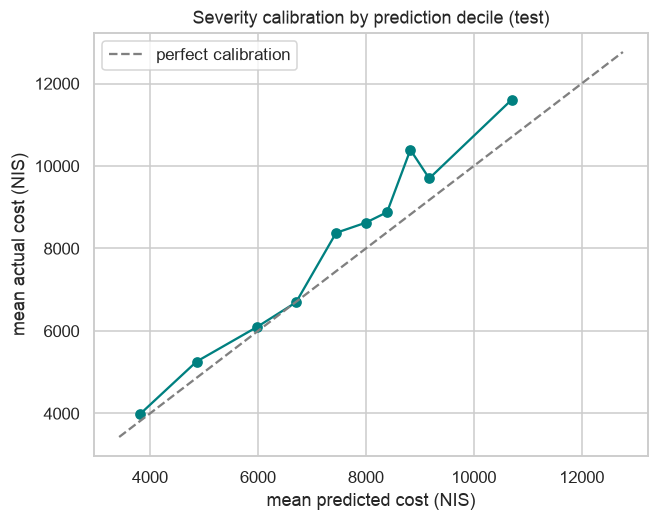

In [9]:
decile_df = pd.DataFrame({"pred": sev_pred_test, "actual": y_sev_test.values})
decile_df["decile"] = pd.qcut(decile_df["pred"], 10, labels=False, duplicates="drop")
decile_means = decile_df.groupby("decile")[["pred", "actual"]].mean()

plt.figure(figsize=(6.5, 5))
plt.plot(decile_means["pred"], decile_means["actual"], marker="o", color="teal")
lims = [decile_means.values.min() * 0.9, decile_means.values.max() * 1.1]
plt.plot(lims, lims, linestyle="--", color="gray", label="perfect calibration")
plt.xlabel("mean predicted cost (NIS)")
plt.ylabel("mean actual cost (NIS)")
plt.title("Severity calibration by prediction decile (test)")
plt.legend()
plt.show()

## Feature importance

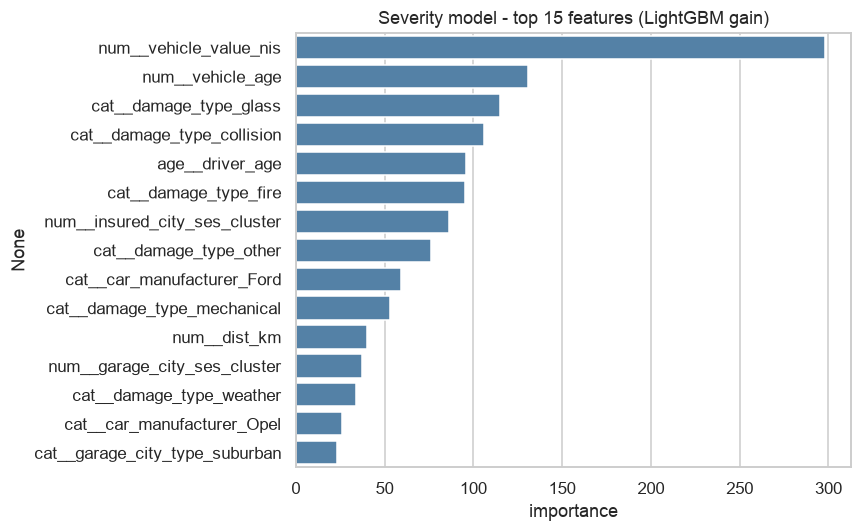

In [10]:
fitted_pipe = severity_model.regressor_
feature_names = fitted_pipe.named_steps["prep"].get_feature_names_out()
importances = fitted_pipe.named_steps["model"].feature_importances_

imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Severity model - top 15 features (LightGBM gain)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

# Part 2 - Garage choice model

## A note on the "imbalance"

The positive rate in the panel is 1%, but this is not a classic imbalanced-classification problem - it's structural: exactly one positive out of 100 candidates per claim, by construction. So no resampling (SMOTE/oversampling would distort the probabilities the ranking needs) and no `scale_pos_weight` (it would break calibration). The natural distribution is kept, and evaluation is done with ranking metrics plus a calibration check.

## Baselines

- **Nearest garage rule:** rank candidates by distance, no model at all. Step 2 showed this alone captures a large share of choices - so this, not random guessing (1%), is the bar to beat.
- **Logistic regression:** linear baseline with scaling inside its own pipeline.

In [11]:
# distance features can be NaN when the insured's coordinates are unknown:
# imputed for the linear baseline, passed through as NaN for LightGBM.
cho_dist = ["dist_km", "log_dist_km", "dist_rank"]
cho_pass = ["ses_delta", "city_type_match", "garage_manufacturer_share",
            "garage_city_ses_cluster", "insured_city_ses_cluster"]
cho_cat = ["garage_city_type", "insured_city_type", "opened_by", "car_manufacturer"]
cho_features = cho_dist + cho_pass + cho_cat

cho_train = choice[choice["split"] == "train"].copy()
cho_test = choice[choice["split"] == "test"].copy()

X_cho_train, y_cho_train = cho_train[cho_features], cho_train["chosen"]
X_cho_test, y_cho_test = cho_test[cho_features], cho_test["chosen"]
train_groups = cho_train["claim_id"]

print(f"train: {X_cho_train.shape} ({cho_train['claim_id'].nunique()} claims)")
print(f"test:  {X_cho_test.shape} ({cho_test['claim_id'].nunique()} claims)")

train: (160000, 12) (1600 claims)
test:  (40000, 12) (400 claims)


In [12]:
# nearest garage rule - closest candidate wins
cho_test["score_nearest"] = -cho_test["dist_km"]
nearest_metrics = ranking_report(cho_test, "score_nearest")
print("nearest garage rule:", {k: round(v, 3) for k, v in nearest_metrics.items()})

nearest garage rule: {'recall@1': np.float64(0.458), 'recall@3': np.float64(0.755), 'recall@5': np.float64(0.868), 'MRR': np.float64(0.631), 'mean_rank': np.float64(3.032)}


In [13]:
# logistic regression baseline - scaling lives inside this pipeline only (trees don't need it)
logreg_prep = ColumnTransformer([
    ("dist", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), cho_dist),
    ("num", StandardScaler(), cho_pass),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cho_cat),
])
logreg_model = Pipeline([
    ("prep", logreg_prep),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
])
logreg_model.fit(X_cho_train, y_cho_train)

cho_test["p_logreg"] = logreg_model.predict_proba(X_cho_test)[:, 1]
logreg_metrics = ranking_report(cho_test, "p_logreg")
print("logistic regression:", {k: round(v, 3) for k, v in logreg_metrics.items()})

logistic regression: {'recall@1': np.float64(0.465), 'recall@3': np.float64(0.755), 'recall@5': np.float64(0.868), 'MRR': np.float64(0.634), 'mean_rank': np.float64(3.045)}


## LightGBM pipeline with Optuna

Tuning detail that matters here: cross validation uses **GroupKFold on `claim_id`**, so all 100 rows of a claim always land in the same fold. Splitting a claim's rows across folds would leak the claim's context between train and validation and make CV scores optimistic. The objective is log loss - aligned with wanting calibrated probabilities for the combined ranking, not just a good ordering.

In [14]:
def make_choice_model(**lgbm_params) -> Pipeline:
    """Full choice pipeline: impute + encode + LGBM classifier."""
    prep = ColumnTransformer([
        ("num", "passthrough", cho_dist + cho_pass),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cho_cat),
    ])
    model = LGBMClassifier(random_state=SEED, verbosity=-1, **lgbm_params)
    return Pipeline([("prep", prep), ("model", model)])


gkf = GroupKFold(n_splits=3)


def choice_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }
    scores = cross_val_score(
        make_choice_model(**params), X_cho_train, y_cho_train,
        groups=train_groups, cv=gkf, scoring="neg_log_loss", n_jobs=-1,
    )
    return -scores.mean()


cho_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
cho_study.optimize(choice_objective, n_trials=15, show_progress_bar=False)

print(f"best CV log loss: {cho_study.best_value:.5f}")
print("best params:", cho_study.best_params)

best CV log loss: 0.02562
best params: {'n_estimators': 300, 'learning_rate': 0.020378441581739508, 'num_leaves': 36, 'min_child_samples': 20, 'subsample': 0.8520091155081155, 'colsample_bytree': 0.6067051337885694, 'reg_lambda': 3.8474712213565283}


## Results and overfitting check

In [15]:
choice_model = make_choice_model(**cho_study.best_params)
choice_model.fit(X_cho_train, y_cho_train)

cho_train["p_lgbm"] = choice_model.predict_proba(X_cho_train)[:, 1]
cho_test["p_lgbm"] = choice_model.predict_proba(X_cho_test)[:, 1]

results_choice = pd.DataFrame({
    "nearest garage rule": nearest_metrics,
    "logistic regression": logreg_metrics,
    "lightgbm": ranking_report(cho_test, "p_lgbm"),
}).T
print("test set comparison (ranking metrics):")
print(results_choice.round(3))

print()
print("overfitting check (log loss):")
print(f"  train: {log_loss(y_cho_train, cho_train['p_lgbm']):.5f}")
print(f"  CV:    {cho_study.best_value:.5f}")
print(f"  test:  {log_loss(y_cho_test, cho_test['p_lgbm']):.5f}")

print()
print("overfitting check (ranking, recall@3):")
print(f"  train: {ranking_report(cho_train, 'p_lgbm')['recall@3']:.3f}")
print(f"  test:  {ranking_report(cho_test, 'p_lgbm')['recall@3']:.3f}")

test set comparison (ranking metrics):
                     recall@1  recall@3  recall@5    MRR  mean_rank
nearest garage rule     0.458     0.755     0.868  0.631      3.032
logistic regression     0.465     0.755     0.868  0.634      3.045
lightgbm                0.445     0.748     0.865  0.620      3.125

overfitting check (log loss):
  train: 0.02306
  CV:    0.02562
  test:  0.02634

overfitting check (ranking, recall@3):
  train: 0.794
  test:  0.748


Honest read: the model essentially matches the nearest-garage rule on ranking metrics (and both are far above the 1% random floor). Train and test are close, so this is a generalization ceiling, not overfitting - in this data, garage choice is driven almost entirely by proximity, and features like SES fit or locality match are correlated with distance rather than adding on top of it.

So why keep the model? Because the rule can only order candidates, while the model produces a calibrated probability for every one of the 100 candidates - which is exactly what the combined cost/likelihood ranking in Part 3 needs. And the framework is ready to absorb signal the rule can't (popularity, service quality, capacity) the moment richer data exists. Worth noting: a first version of this model *appeared* to beat the rule easily, and it was a leakage artifact in the popularity feature (fixed with leave-one-out encoding in Step 2) - a good reminder that beating a strong simple baseline should raise questions before it raises confidence.

## Probability calibration

Two views. First, a reliability curve on the raw per-row probabilities. Second, since exactly one garage is chosen per claim, the per-row probabilities are normalized to sum to 1 within each claim - this turns the binary classifier's output into a proper choice distribution over the candidate set, which is what the combined ranking consumes.

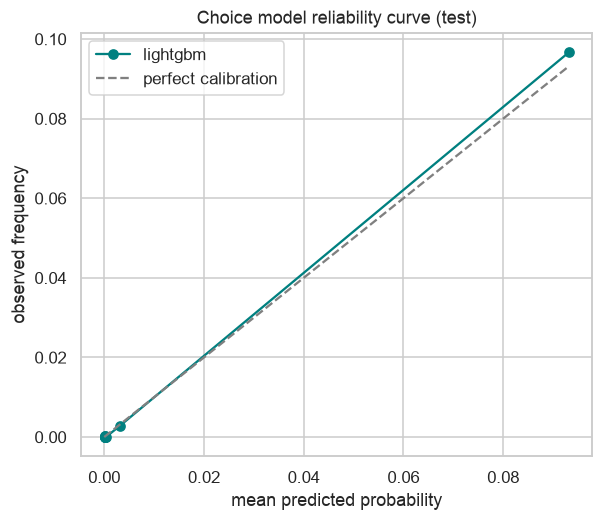

normalized probabilities sum to 1 per claim: True


In [16]:
frac_pos, mean_pred = calibration_curve(y_cho_test, cho_test["p_lgbm"], n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, frac_pos, marker="o", color="teal", label="lightgbm")
plt.plot([0, mean_pred.max()], [0, mean_pred.max()], linestyle="--", color="gray", label="perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("observed frequency")
plt.title("Choice model reliability curve (test)")
plt.legend()
plt.show()

# normalize within claim - a proper probability distribution over the 100 candidates
cho_test["p_norm"] = cho_test["p_lgbm"] / cho_test.groupby("claim_id")["p_lgbm"].transform("sum")
print("normalized probabilities sum to 1 per claim:",
      np.allclose(cho_test.groupby("claim_id")["p_norm"].sum(), 1.0))

## Feature importance

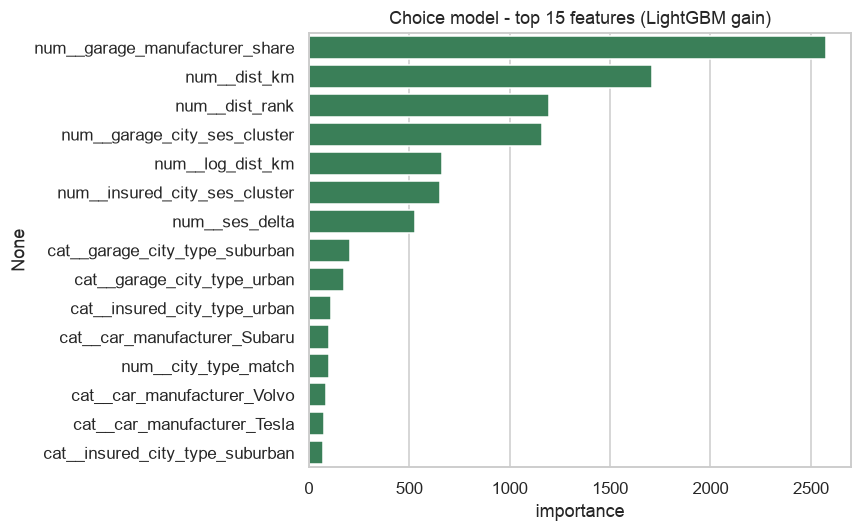

In [17]:
cho_names = choice_model.named_steps["prep"].get_feature_names_out()
cho_imp = pd.Series(choice_model.named_steps["model"].feature_importances_, index=cho_names)
cho_imp = cho_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=cho_imp.values, y=cho_imp.index, color="seagreen")
plt.title("Choice model - top 15 features (LightGBM gain)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

# Part 3 - Combined garage ranking

The final deliverable: for each claim, a ranked list of garages combining the likelihood the customer actually goes there with the expected repair cost there.

**How the two models meet:** for every candidate garage of a test claim, the severity pipeline predicts the expected cost with that candidate's garage features plugged in, and the choice model gives the (normalized) probability the customer picks it. The ranking score is:

`score = p_norm * (1 - lam * cost_scaled)`

where `cost_scaled` is the expected cost min-max scaled within the claim's candidate set, and `lam` is a business knob: `lam = 0` ranks purely by likelihood, larger `lam` pushes cheaper garages up the list. The multiplicative form matters: a garage the customer would never go to (probability near zero) can't be rescued by being cheap - an additive score would happily recommend a garage 200 km away just because it's inexpensive. Presenting `lam` as a knob is deliberate - where to sit on this trade-off is a business decision, not a modeling one.

In [18]:
rank_df = cho_test.copy()

# expected cost per candidate: severity pipeline scored with each candidate's garage features
rank_df["expected_cost"] = severity_model.predict(rank_df[sev_features])

# scale cost within each claim's candidate set
grp = rank_df.groupby("claim_id")["expected_cost"]
cost_range = (grp.transform("max") - grp.transform("min")).replace(0, 1)
rank_df["cost_scaled"] = (rank_df["expected_cost"] - grp.transform("min")) / cost_range

summary_rows = []
for lam in [0.0, 0.2, 0.5, 1.0]:
    rank_df["score"] = rank_df["p_norm"] * (1 - lam * rank_df["cost_scaled"])
    rank_df["final_rank"] = rank_df.groupby("claim_id")["score"].rank(ascending=False, method="first")
    top3 = rank_df[rank_df["final_rank"] <= 3]
    top1 = rank_df[rank_df["final_rank"] == 1]
    summary_rows.append({
        "lam": lam,
        "top3 hit rate": rank_df.loc[rank_df["chosen"] == 1, "final_rank"].le(3).mean(),
        "top1 hit rate": rank_df.loc[rank_df["chosen"] == 1, "final_rank"].le(1).mean(),
        "mean expected cost of top1": top1["expected_cost"].mean(),
        "mean expected cost of top3": top3["expected_cost"].mean(),
    })

tradeoff = pd.DataFrame(summary_rows).set_index("lam")
print(tradeoff.round(3))

     top3 hit rate  top1 hit rate  mean expected cost of top1  mean expected cost of top3
lam                                                                                      
0.0          0.748          0.445                    7390.079                    7389.834
0.2          0.750          0.445                    7389.883                    7389.141
0.5          0.750          0.445                    7389.176                    7387.947
1.0          0.605          0.362                    7359.575                    7353.162


This table is the business story in one place: moving `lam` up trades a bit of "we recommend where the customer would go anyway" (hit rate) for a cheaper recommended list (expected cost). The claims team can pick the operating point.

In [19]:
# example output - the ranked list for one test claim, lam fixed at 0.2
LAM = 0.2
rank_df["score"] = rank_df["p_norm"] * (1 - LAM * rank_df["cost_scaled"])
rank_df["final_rank"] = rank_df.groupby("claim_id")["score"].rank(ascending=False, method="first")

example_claim = rank_df["claim_id"].iloc[0]
example = (
    rank_df[rank_df["claim_id"] == example_claim]
    .merge(garages[["garage_id", "garage_name"]], left_on="candidate_garage_id", right_on="garage_id")
    .sort_values("final_rank")
    .head(5)
)
print(f"top 5 recommended garages for claim {example_claim} (lam={LAM}):")
example[["final_rank", "garage_name", "dist_km", "p_norm", "expected_cost", "score", "chosen"]].round(3)

top 5 recommended garages for claim 796 (lam=0.2):


,final_rank,garage_name,dist_km,p_norm,expected_cost,score,chosen
31,1.0,GAR_046,0.000,0.499,8751.754,0.408,1
24,2.0,GAR_019,30.914,0.197,8815.211,0.158,0
46,3.0,GAR_029,20.776,0.102,8670.611,0.086,0
40,4.0,GAR_123,30.914,0.042,8815.211,0.033,0
61,5.0,GAR_109,32.000,0.035,8769.650,0.028,0


**Known limitation:** the expected cost per candidate extrapolates from costs observed only at garages that were actually chosen, so cross-garage cost differences carry selection bias. The honest read is that the cost side of the ranking is a v1 estimate; a causal correction (e.g. doubly robust estimation) is the right next step before using it to steer customers at scale.

# Saving the pipeline artifacts

Each artifact is a full sklearn Pipeline - imputation, encoding and model in one object - saved with joblib via `src/io_utils.py`. The metadata file records the feature lists (which the inference module reads back, so training and serving can't disagree on columns), tuned parameters, test metrics and package versions. The full inference bundle is the two pipelines plus the reference tables from Step 2 (garages, candidate sets, popularity lookup, city reference) - the model is the smallest part of the artifact. The reload check proves it's self-contained.

In [20]:
from src.io_utils import save_metadata, save_model

save_model(severity_model, "severity_pipeline")
save_model(choice_model, "choice_pipeline")

metadata = {
    "severity": {
        "features": sev_features,
        "best_params": sev_study.best_params,
        "test_metrics": {k: float(v) for k, v in regression_report(y_sev_test, sev_pred_test).items()},
    },
    "choice": {
        "features": cho_features,
        "best_params": cho_study.best_params,
        "test_metrics": {k: float(v) for k, v in ranking_report(cho_test, "p_lgbm").items()},
    },
    "split": "chronological 80/20 by event_date",
    "ranking_score": "p_norm - lam * cost_scaled (lam is a business knob)",
    "versions": {
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "lightgbm": lightgbm.__version__,
    },
}
save_metadata(metadata)

print("saved: models/severity_pipeline.pkl, models/choice_pipeline.pkl, models/metadata.json")

saved: models/severity_pipeline.pkl, models/choice_pipeline.pkl, models/metadata.json


In [21]:
# reload check - a cold process should get identical predictions from the pkl alone
sev_loaded = joblib.load("models/severity_pipeline.pkl")
cho_loaded = joblib.load("models/choice_pipeline.pkl")

assert np.allclose(sev_loaded.predict(X_sev_test.head()), severity_model.predict(X_sev_test.head()))
assert np.allclose(
    cho_loaded.predict_proba(X_cho_test.head())[:, 1],
    choice_model.predict_proba(X_cho_test.head())[:, 1],
)
print("reload check passed - artifacts are self-contained")

reload check passed - artifacts are self-contained


# Inference - from a raw claim to a ranked list

`src/inference.py` exposes `rank_garages(claim, lam, top_k)` - the production scoring path. The input is a raw claim as a claims system would send it, with all model features required and used as given. The only fields that may arrive missing or dirty are the three that showed real quality issues in the data: `driver_age` (outliers get the same 17-90 rule as training, then the pipeline's train-fitted median), and `insured_lat`/`insured_lon` (completed from the train-built city centroid; for an unknown city they stay NaN and the tree models handle the missing distance natively). Candidate expansion, distances, and the popularity lookup all happen inside, with the same `src/features.py` code the panels used.

In [22]:
from src.inference import rank_garages

example_row = pd.read_csv("data/claims_clean.csv").iloc[0]
claim = {
    "car_manufacturer": example_row["car_manufacturer"],
    "vehicle_age": example_row["vehicle_age"],
    "vehicle_value_nis": example_row["vehicle_value_nis"],
    "driver_age": 42,
    "damage_type": example_row["damage_type"],
    "opened_by": example_row["opened_by"],
    "insured_city_id": example_row["insured_city_id"],
    "insured_city_type": example_row["insured_city_type"],
    "insured_city_ses_cluster": example_row["insured_city_ses_cluster"],
    "insured_lat": example_row["insured_lat"],
    "insured_lon": example_row["insured_lon"],
}

rank_garages(claim, lam=0.2, top_k=5)

,candidate_garage_id,garage_name,dist_km,p_choice,expected_cost_nis,score
0,78,GAR_078,4.687886,0.344402,7407.603671,0.277376
1,15,GAR_015,4.687886,0.240382,7407.603671,0.193599
2,5,GAR_005,4.687886,0.166910,7407.603671,0.134427
3,124,GAR_124,23.614561,0.119975,7422.405296,0.095980
4,103,GAR_103,45.123221,0.040422,7334.674710,0.033628


In [23]:
# same claim arriving dirty: coordinates unknown, driver age is a sentinel value.
# coordinates fall back to the train city centroid, the age becomes NaN and gets the train median.
claim_dirty = {**claim, "insured_lat": None, "insured_lon": None, "driver_age": 999}
rank_garages(claim_dirty, lam=0.2, top_k=5)

,candidate_garage_id,garage_name,dist_km,p_choice,expected_cost_nis,score
0,78,GAR_078,4.687886,0.344402,7407.603671,0.277376
1,15,GAR_015,4.687886,0.240382,7407.603671,0.193599
2,5,GAR_005,4.687886,0.166910,7407.603671,0.134427
3,124,GAR_124,23.614561,0.119975,7422.405296,0.095980
4,103,GAR_103,45.123221,0.040422,7334.674710,0.033628


The unit tests in `tests/test_inference.py` cover this contract: full input used as-is, the centroid fallback reproducing the full-input result, outlier ages not crashing, probabilities summing to 1 over the candidate set, and hard failures on missing required fields or an unknown manufacturer. Run with `pytest` from the project root.

# Findings and next steps

**What the models learned:**
- Severity is driven mostly by damage type and vehicle value, matching the EDA picture. The GBM only marginally edges the naive median baseline and Ridge - most of the remaining variance behaves like noise, so a simple explainable model is a legitimate alternative here.
- Garage choice is dominated by proximity: the tuned model matches the nearest-garage rule but can't beat it, because in this data there's little signal beyond distance. Its value is calibrated probabilities over the full candidate set (which a rule can't produce), and a framework ready for richer signals.
- The most instructive result was a negative one: a first version of the choice model "beat" the baseline through target leakage in the popularity feature. Leave-one-out encoding fixed it, and the train/test gap closed. Beating a strong simple baseline too easily is a red flag, not a win.
- The combined ranking makes the cost/likelihood trade-off explicit through a single knob, so the operating point is a business decision backed by a table, not something buried in the code.

**With more time, next steps in order of expected value:**
1. **Selection bias in cross-garage costs** - we only see costs where customers actually went. Doubly robust / causal estimation before using cost differences to steer customers.
2. **Routing distance instead of haversine** - real driving time is the actual friction; haversine is a v1 stand-in.
3. **Gamma/Tweedie objective for severity** - trains directly in NIS on a right-skewed target and removes the log-retransformation bias.
4. **Ranking objective for choice** - LightGBM's lambdarank (or a conditional logit) matches the one-of-100 structure more directly than a binary classifier, and would be the natural home for richer garage-level signals.
5. **Richer garage features** - capacity, ratings, service quality. That's the data that would let the choice model finally beat geography.
6. **Monitoring** - the pipelines are ready for pkl deployment; adding drift checks on distance and cost distributions would close the loop.

**Project structure:** shared logic in `src/` (features, io, inference), notebooks for the narrative, `tests/` for the serving contract, artifacts in `models/`. The notebooks import from `src` instead of redefining functions, so the code that trained the models is the code that serves them.